# Experiment: Holy QOW Post-6A Steps 0–2 Evidence

**Objective:** reproduce the frozen-artifact checks, conditional analysis, held-out evaluation, D=6 repeatability analysis, and figures from saved evidence.

**Safety boundary:** this notebook does not submit Classiq jobs, overwrite quantum runs, implement Step 3, or change the frozen model. The four new quantum runs are already saved.

**Success criteria:** all gates pass; matched-valid batches use the actual QAOA one-hot count; held-out scenarios remain frozen; all five optimizer seeds, including poor seeds, appear in the final tables.

In [1]:
# Setup: locate the repository and use its verified Python environment.
from __future__ import annotations

import json
import os
from pathlib import Path
import subprocess
import sys

import pandas as pd
from IPython.display import Image, display

def find_implementation_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'post6a').is_dir() and (candidate / 'stage6a').is_dir():
            return candidate
    raise FileNotFoundError('Open this notebook from the Holy QOW implementation checkout')

ROOT = find_implementation_root(Path.cwd())
verified_python = ROOT.parent / '.venv-classiq' / 'Scripts' / 'python.exe'
PYTHON = str(verified_python if verified_python.is_file() else Path(sys.executable))
ARTIFACTS = ROOT / 'artifacts' / 'post6a'

def run_script(relative_path: str) -> str:
    completed = subprocess.run(
        [PYTHON, str(ROOT / relative_path)],
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
        env={**os.environ, 'MPLBACKEND': 'Agg', 'MPLCONFIGDIR': str(ARTIFACTS / '.mplconfig')},
    )
    lines = [line for line in completed.stdout.splitlines() if line.strip()]
    return lines[-1] if lines else 'completed'

{'root': str(ROOT), 'python': PYTHON, 'artifact_root': str(ARTIFACTS)}

{'root': 'C:\\Users\\ohada\\Documents\\QUBIT Hackathon\\implementation',
 'python': 'C:\\Users\\ohada\\Documents\\QUBIT Hackathon\\.venv-classiq\\Scripts\\python.exe',
 'artifact_root': 'C:\\Users\\ohada\\Documents\\QUBIT Hackathon\\implementation\\artifacts\\post6a'}

## Plan

1. Reprocess frozen D=4–6 evidence and verify recorded summaries.
2. Recompute Step 0 conditional and matched-valid metrics without quantum execution.
3. Evaluate the pre-frozen held-out manifest and fixed routes.
4. Reprocess all five saved D=6 seeds and deterministic controls.
5. Regenerate figures and optionally rerun the three test suites.

## Gate 0A — Frozen artifact consistency

In [2]:
run_script('post6a/scripts/verify_frozen_baseline.py')
baseline = json.loads((ARTIFACTS / 'baseline_verification.json').read_text())
{
    'status': baseline['status'],
    'decoded_shots': {row['D']: row['decoded_shots'] for row in baseline['runs']},
    'discrepancies': baseline['discrepancies'],
}

{'status': 'PASS',
 'decoded_shots': {4: 4096, 5: 4096, 6: 4096},
 'discrepancies': []}

## Step 0 — Conditional distribution

Each random-valid null batch contains exactly the number of one-hot QAOA shots observed at that D.

In [3]:
run_script('post6a/scripts/run_step0_conditional.py')
conditional = pd.read_csv(ARTIFACTS / 'conditional' / 'conditional_metrics.csv')
conditional[[
    'D', 'one_hot_count', 'joint_feasible_count', 'near_optimal_count',
    'p_one_hot', 'p_joint_feasible', 'p_feasible_given_onehot',
    'p_near_optimal_given_onehot', 'best_feasible_objective_gap',
]]

,D,one_hot_count,joint_feasible_count,near_optimal_count,p_one_hot,p_joint_feasible,p_feasible_given_onehot,p_near_optimal_given_onehot,best_feasible_objective_gap
0,4,214,96,2,0.052246,0.023438,0.448598,0.009346,0.000000
1,5,24,8,1,0.005859,0.001953,0.333333,0.041667,0.000972
2,6,25,8,1,0.006104,0.001953,0.320000,0.040000,0.008357


In [4]:
matched0 = pd.read_csv(ARTIFACTS / 'conditional' / 'matched_valid_summary.csv')
matched0[[
    'D', 'matched_batch_size',
    'empirical_p_random_best_gap_at_least_as_good',
    'empirical_p_random_best_regret_at_least_as_good',
    'empirical_p_random_feasible_fraction_at_least_as_high',
    'empirical_p_random_near_fraction_at_least_as_high',
]]

,D,matched_batch_size,empirical_p_random_best_gap_at_least_as_good,empirical_p_random_best_regret_at_least_as_good,empirical_p_random_feasible_fraction_at_least_as_high,empirical_p_random_near_fraction_at_least_as_high
0,4,214,0.920080,0.996004,0.857143,0.729271
1,5,24,0.192807,0.192807,0.442557,0.328671
2,6,25,0.222777,0.204795,0.296703,0.315684


**Step 0 result:** one-hot access is the dominant multiplicative loss. Conditional superiority is not established: every matched-valid empirical p-value is above 0.19.

## Step 1 — Held-out resilience

The scenario and route manifests were frozen before comparison. This cell evaluates those frozen inputs; it does not regenerate or tune them.

In [5]:
run_script('post6a/scripts/run_step1_heldout.py')
heldout = pd.read_csv(ARTIFACTS / 'heldout' / 'heldout_route_summary.csv')
heldout[[
    'route_id', 'assignment', 'mean_regret', 'worst_case_regret',
    'survival_rate', 'violating_scenarios', 'maximum_overflow',
    'mean_weighted_latency',
]]

,route_id,assignment,mean_regret,worst_case_regret,survival_rate,violating_scenarios,maximum_overflow,mean_weighted_latency
0,nominal_only,"[0, 1, 1, 0]",0.024654,0.234700,0.833333,4,0.4,30.283333
1,static_uniform_multiscenario,"[1, 0, 2, 2]",0.075445,0.316311,1.000000,0,0.0,36.137500
2,exact_adaptive,"[0, 1, 1, 2]",0.146990,0.478334,0.916667,2,0.4,33.911667
3,qaoa_adaptive,"[0, 1, 1, 2]",0.146990,0.478334,0.916667,2,0.4,33.911667
4,exact_pure_minimax,"[0, 1, 1, 2]",0.146990,0.478334,0.916667,2,0.4,33.911667


**Step 1 result:** the static uniform route is the only 24/24 survivor. Exact-adaptive, QAOA-adaptive, and minimax are the same assignment and underperform the static route on survival and regret.

## Step 2 — D=6 repeatability from saved raw runs

This invokes post-processing only. It does not execute Classiq.

In [6]:
run_script('post6a/scripts/process_step2_repeatability.py')
repeat = pd.read_csv(ARTIFACTS / 'repeatability' / 'd6_repeatability.csv')
qaoa = repeat[repeat['method'].eq('qaoa')]
qaoa[[
    'optimizer_seed', 'one_hot_count', 'joint_feasible_count',
    'near_optimal_count', 'p_one_hot', 'p_joint_feasible',
    'p_feasible_given_onehot', 'p_near_optimal_given_onehot',
    'best_feasible_objective_gap', 'best_feasible_worst_case_regret',
    'execution_runtime_seconds', 'execution_status',
]]

,optimizer_seed,one_hot_count,joint_feasible_count,near_optimal_count,p_one_hot,p_joint_feasible,p_feasible_given_onehot,p_near_optimal_given_onehot,best_feasible_objective_gap,best_feasible_worst_case_regret,execution_runtime_seconds,execution_status
0,6106,25,8,1,0.006104,0.001953,0.320000,0.040000,0.008357,0.198829,16.973742,PROCESSED
3,6201,48,11,1,0.011719,0.002686,0.229167,0.020833,0.002162,0.184055,17.617843,RAW_SAMPLE_SAVED
6,6202,5,1,0,0.001221,0.000244,0.200000,0.000000,0.048627,0.363491,10.787270,RAW_SAMPLE_SAVED
9,6203,63,14,1,0.015381,0.003418,0.222222,0.015873,0.003516,0.195556,21.344663,RAW_SAMPLE_SAVED
12,6204,18,6,0,0.004395,0.001465,0.333333,0.000000,0.036005,0.311178,21.975491,RAW_SAMPLE_SAVED


In [7]:
comparison = json.loads((ARTIFACTS / 'repeatability' / 'd6_control_comparison_summary.json').read_text())
comparison

{'best_objective_gap_one_sided_sign_pvalue': 0.03125,
 'best_objective_gap_pairwise_trials': 5,
 'best_objective_gap_pairwise_wins_over_random_bits': 5,
 'best_worst_case_regret_one_sided_sign_pvalue': 0.03125,
 'best_worst_case_regret_pairwise_trials': 5,
 'best_worst_case_regret_pairwise_wins_over_random_bits': 5,
 'joint_feasible_probability_one_sided_sign_pvalue': 0.1875,
 'joint_feasible_probability_pairwise_trials': 5,
 'joint_feasible_probability_pairwise_wins': 4,
 'matched_best_gap_p_below_0_05_seeds': 0,
 'matched_best_regret_p_below_0_05_seeds': 0,
 'matched_conditional_feasible_p_below_0_05_seeds': 0,
 'matched_conditional_near_p_below_0_05_seeds': 0,
 'onehot_probability_one_sided_sign_pvalue': 0.1875,
 'onehot_probability_pairwise_trials': 5,
 'onehot_probability_pairwise_wins': 4,
 'qaoa_conditional_feasible_above_random_valid_seeds': 2,
 'qaoa_conditional_near_above_random_valid_seeds': 3,
 'qaoa_mean_joint_feasible_probability': 0.001953125,
 'qaoa_mean_onehot_probabil

**Step 2 result:** QAOA beats its random-bit control on best feasible gap and regret in 5/5 pairs, but one-hot counts range from 5 to 63 and no matched-valid conditional comparison is significant.

## Figures

01_raw_vs_conditional_probability.png


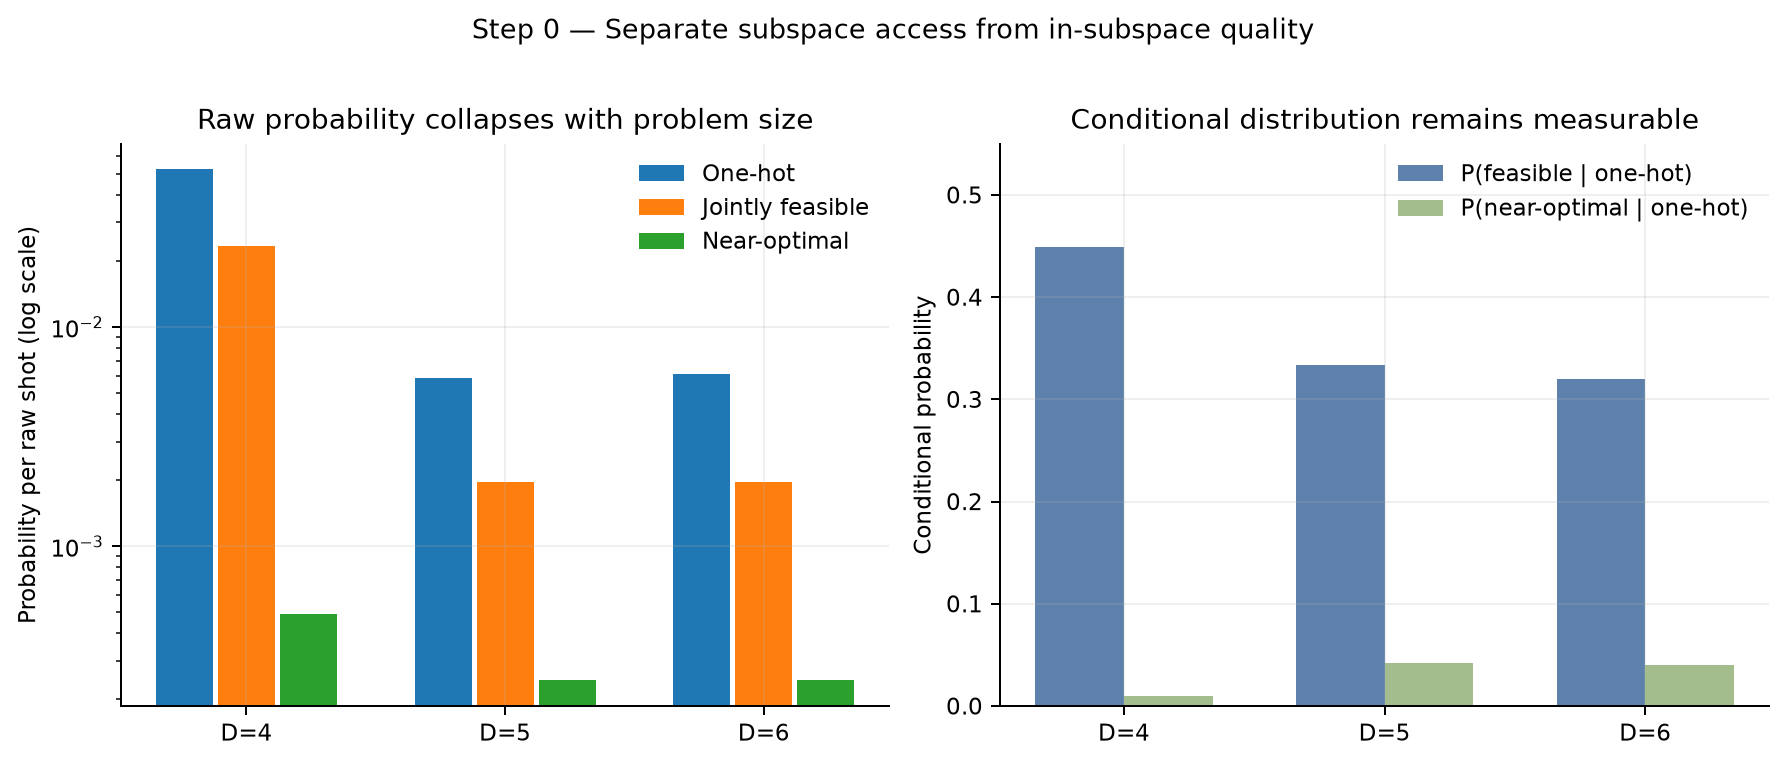

02_matched_valid_quality.png


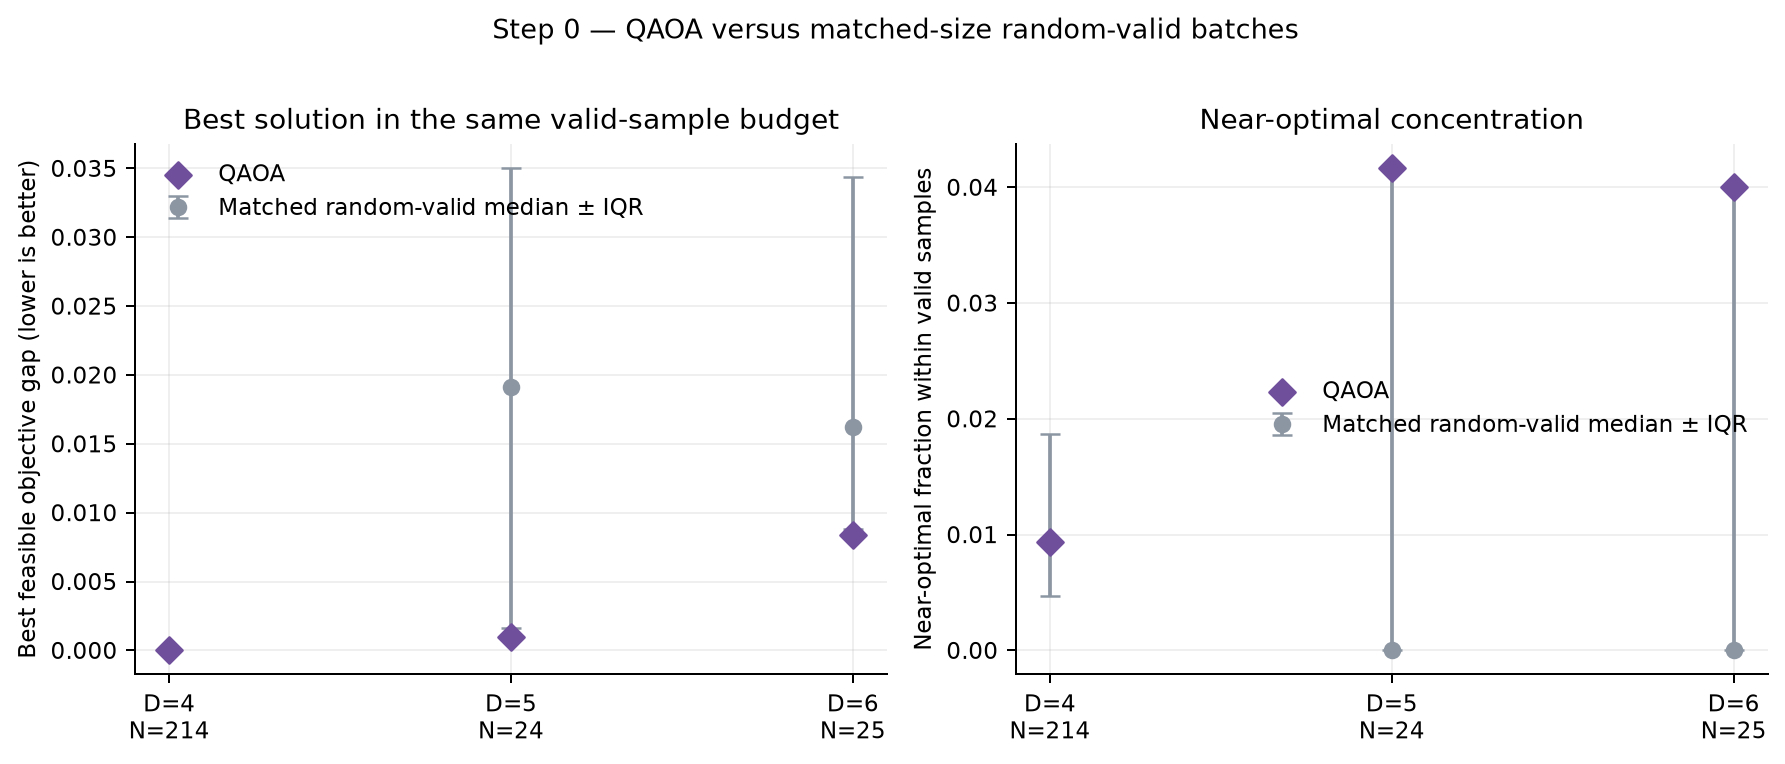

03_heldout_regret_distribution.png


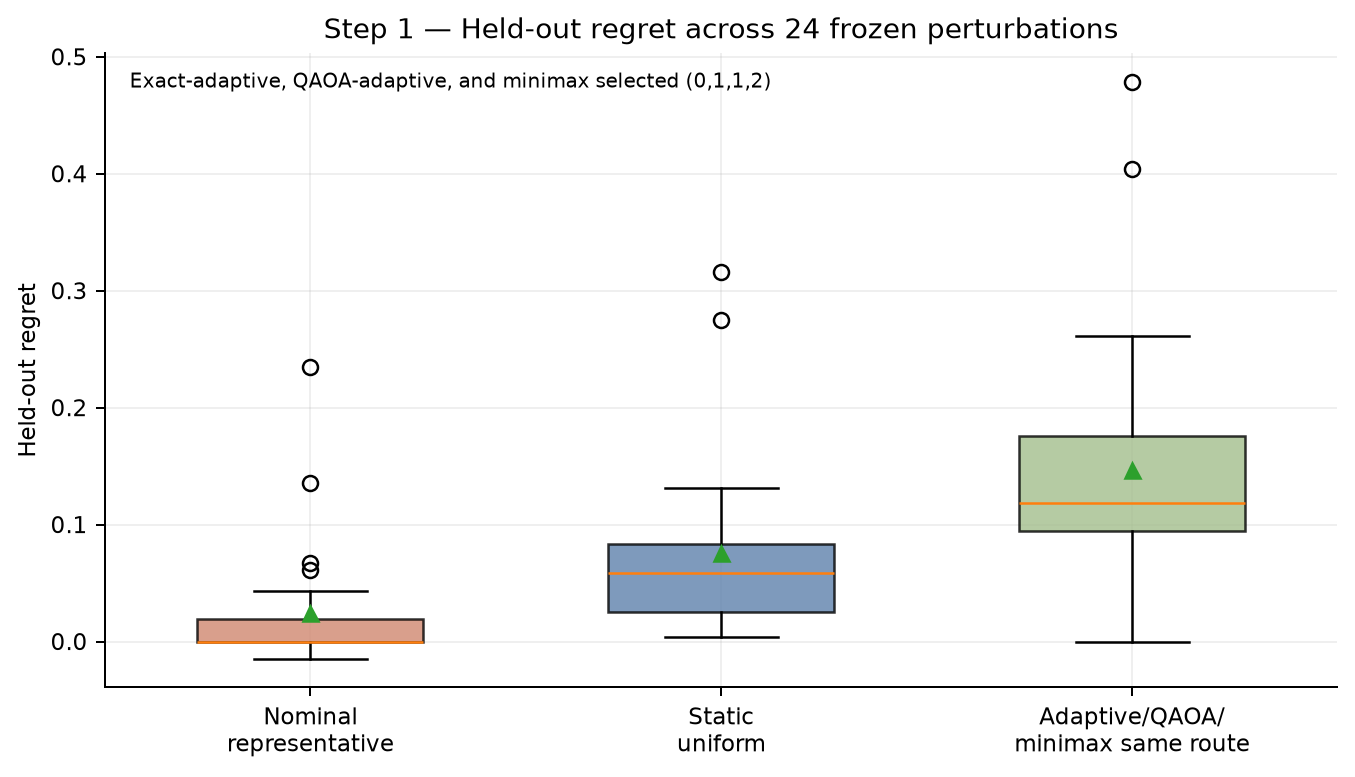

04_heldout_survival.png


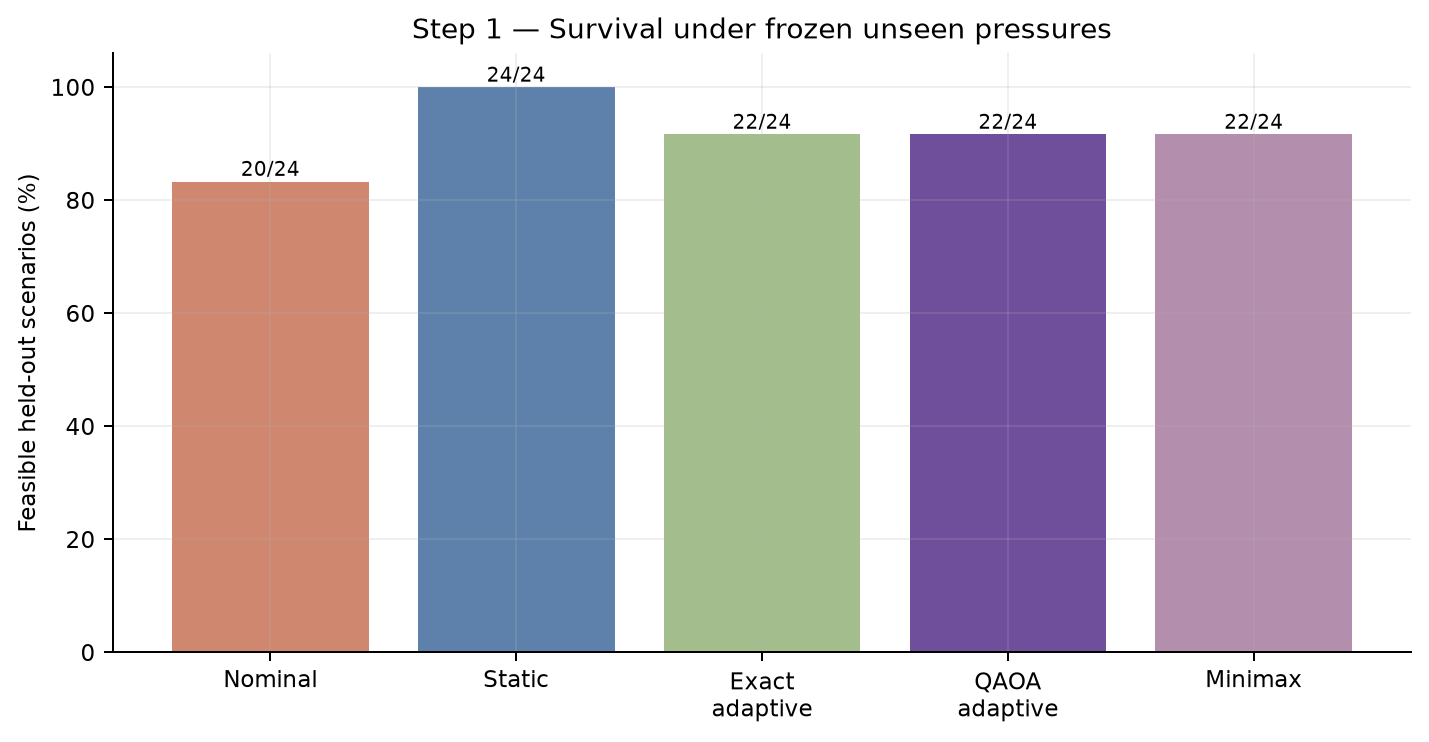

05_d6_seed_repeatability.png


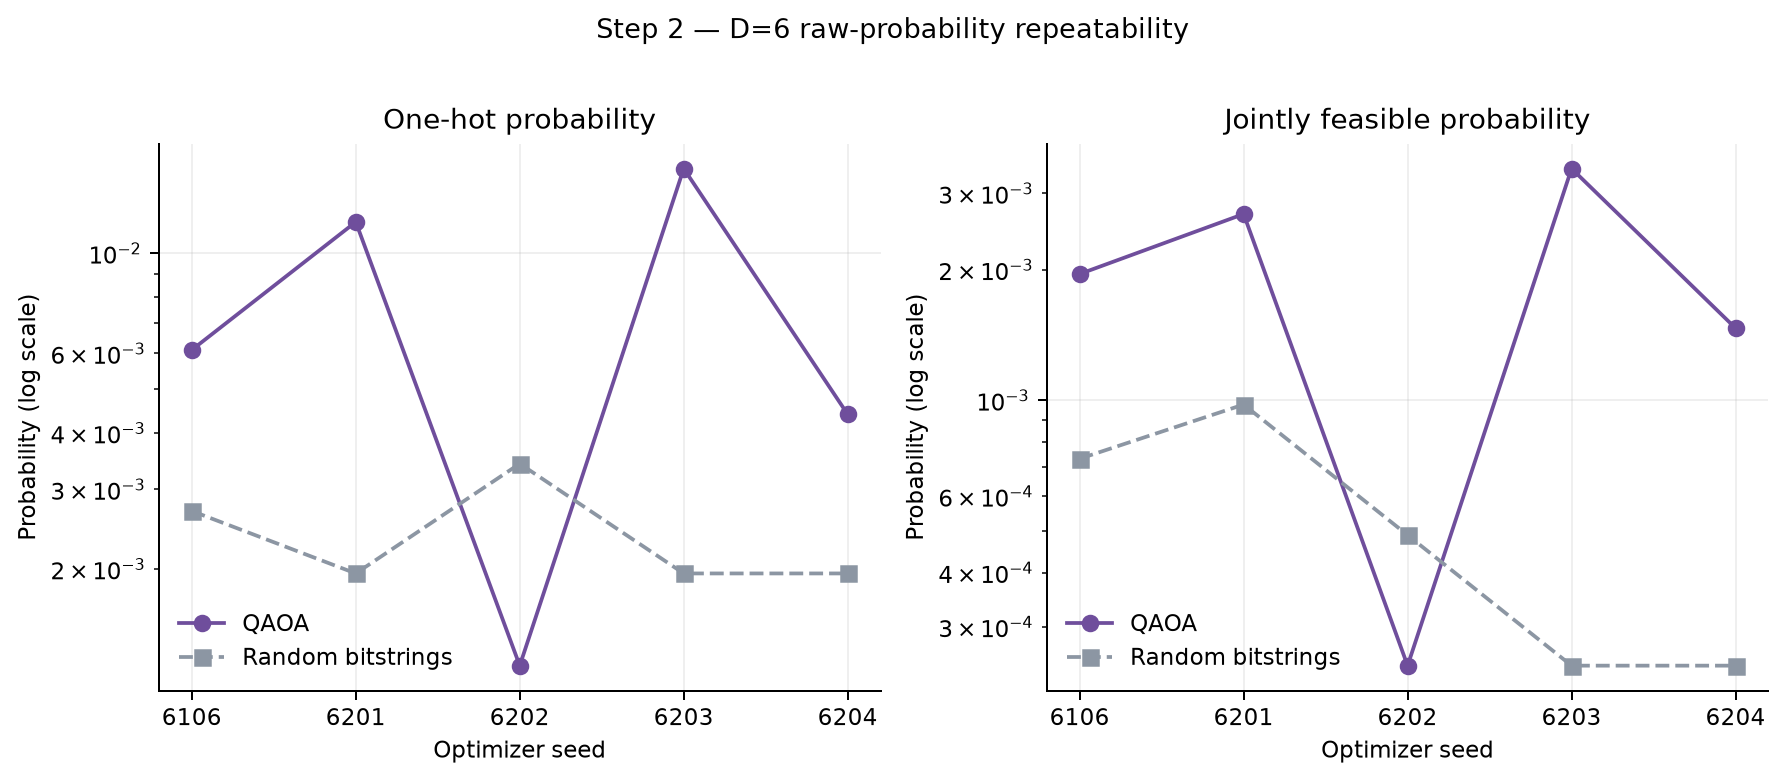

06_d6_conditional_quality_by_seed.png


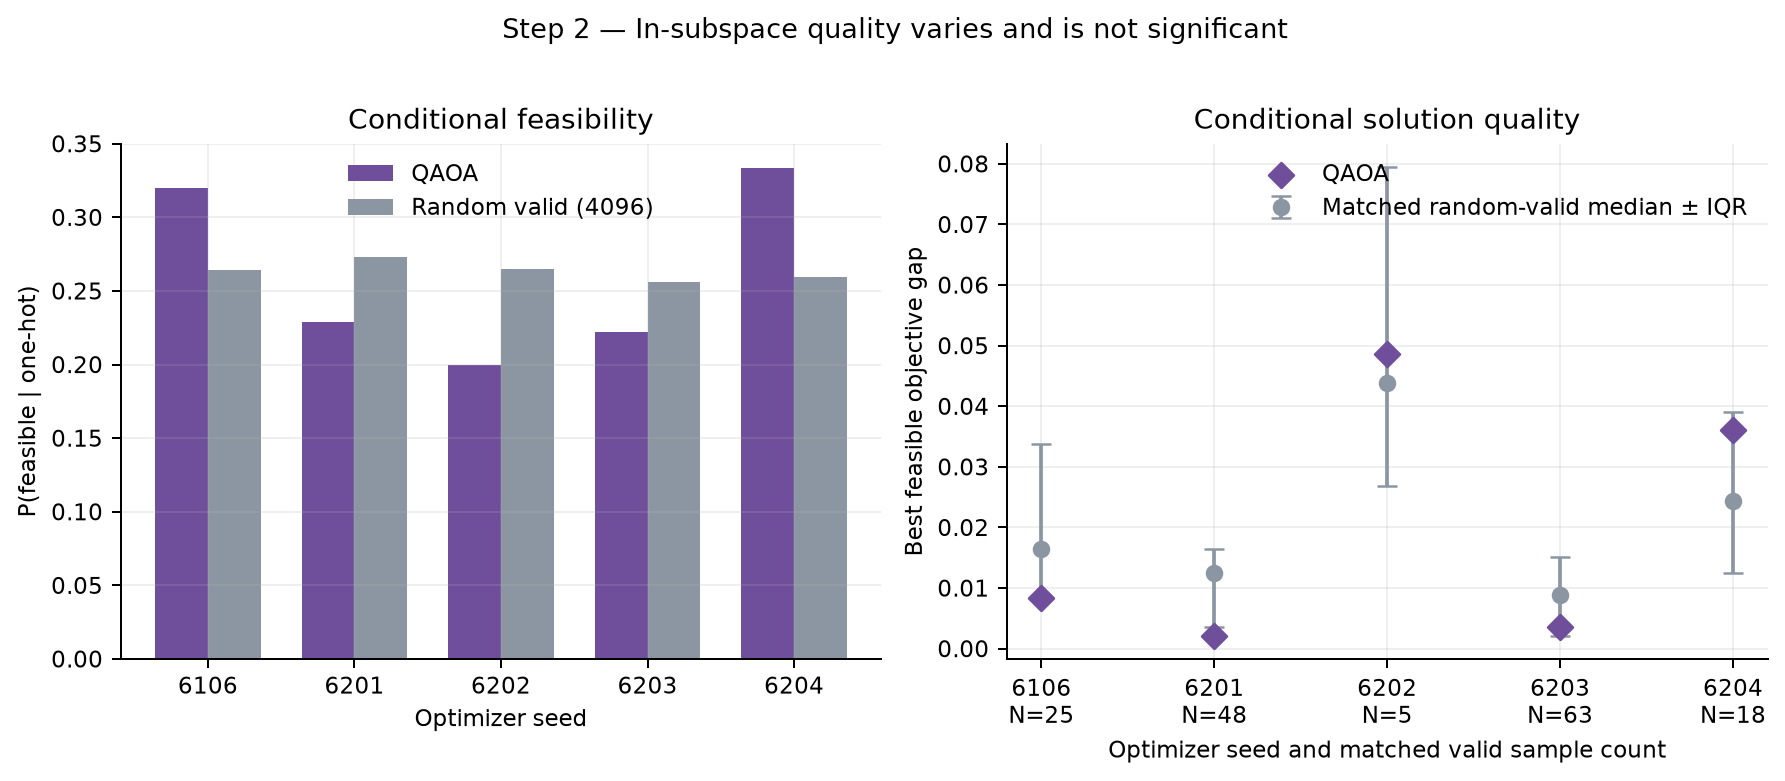

In [8]:
run_script('post6a/scripts/generate_post6a_plots.py')
for figure in sorted((ARTIFACTS / 'figures').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure), width=900))

## Optional verification tests

The Stage 6A suite includes slower exact-enumeration checks and may take several minutes.

In [9]:
def run_tests(path: str) -> str:
    completed = subprocess.run(
        [PYTHON, '-m', 'pytest', path, '-q', '--disable-warnings'],
        cwd=ROOT, check=True, capture_output=True, text=True,
    )
    return completed.stdout.strip().splitlines()[-1]

{
    'v1.1': run_tests('tests'),
    'stage6a': run_tests('stage6a/tests'),
    'post6a': run_tests('post6a/tests'),
}

{'v1.1': '..............................................................           [100%]',
 'stage6a': '31 passed, 1428 warnings in 55.95s',
 'post6a': '9 passed in 10.34s'}

## Decision

The previous Stage 6A interpretation is **weakened, not overturned**. The random-bit comparison is stronger, but conditional concentration and adaptive held-out resilience are not supported.

**STEP 3 RECOMMENDATION: NO-GO**

Stop here until the user explicitly authorizes further work.